In [19]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import os
import time
import random
import urllib.parse
import requests
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib as mpl
from selenium.common.exceptions import NoSuchElementException
import glob


# deck_codes要讓使用者輸入
# deck_codes = input("請輸入牌組代碼（用逗號分隔）: ").split(",")
game_name= "5月月賽 第二場"
deck_codes = ["X8SA","3NLU0","37PB6", "3KHCE", "5J67C", "2QL1Y", "48GVL","42UV8","6AJ3C","208D6","5DU6U","6ZJFG","7A5QE","2817A","2S3Qg","34JAU","63QLC"]



In [9]:
import os
import time
import random
import urllib.parse
import requests
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

# 強化瀏覽器設定
chrome_options = webdriver.ChromeOptions()
chrome_options.add_argument('--headless')
chrome_options.add_argument('--disable-gpu')
chrome_options.add_argument('--no-sandbox')
chrome_options.add_argument('user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36')

service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=chrome_options)

# 處理 Cookie 同意彈窗的函數
def handle_cookie_consent(driver):
    try:
        consent_button = WebDriverWait(driver, 5).until(
            EC.element_to_be_clickable((By.XPATH, '//button[text()="Allow all"]'))
        )
        consent_button.click()
        print("✅ 已自動點擊 Allow all 按鈕")
        time.sleep(2)  # 延長等待時間確保彈窗完全消失
        return True
    except Exception as e:
        print(f"ℹ️ 沒有發現 Cookie 彈窗或已自動關閉: {str(e)}")
        return False

# 強化：自動重試的抓取副程式
def fetch_with_retry(driver, code, is_first=False, max_retries=3, base_delay=2):
    retries = 0
    while retries < max_retries:
        try:
            if not is_first or retries > 0:
                delay = base_delay * (2 ** retries) + random.uniform(0, 2)
                print(f"⏳ 重試等待: {delay:.1f}秒")
                time.sleep(delay)
            url = f'https://decklog-en.bushiroad.com/ja/view/{code}'
            driver.get(url)
            # 首筆資料處理 Cookie
            if is_first and retries == 0:
                cookie_handled = handle_cookie_consent(driver)
                if cookie_handled:
                    print("🔄 重新載入頁面以獲取資料...")
                    driver.get(url)
            # 等待元素
            element = WebDriverWait(driver, 15).until(
                EC.visibility_of_element_located(
                    (By.XPATH, '//p[contains(@class,"preview-top-label-right")]/span')
                )
            )
            title = driver.execute_script(
                'return arguments[0].textContent.trim();', element
            )
            if not title:
                raise ValueError("獲取到空值內容")
            print(f"✅ 成功抓取 {code}: {title}")
            return title
        except Exception as e:
            retries += 1
            print(f"❌ [{code}] 抓取失敗({retries}): {str(e)}")
    print(f"❌ [{code}] 重試{max_retries}次後仍失敗，略過。")
    return None

# 主流程
def fetch_deck_titles_with_retry(deck_codes):
    results = []
    try:
        for idx, code in enumerate(deck_codes):
            print(f"\n🔍 正在處理代碼 ({idx+1}/{len(deck_codes)}) {code}")
            is_first = (idx == 0)
            title = fetch_with_retry(driver, code, is_first=is_first)
            results.append(title)
    finally:
        driver.quit()
    final_results = [x for x in results if x]
    print("\n最終有效結果：")
    print(final_results)
    return final_results

# ====== 使用範例 ======
if __name__ == "__main__":
    print("🔍 開始抓取牌組標題...")
    final_results=fetch_deck_titles_with_retry(deck_codes)
    print("✅ 抓取完成！")


🔍 開始抓取牌組標題...

🔍 正在處理代碼 (1/17) X8SA
✅ 已自動點擊 Allow all 按鈕
🔄 重新載入頁面以獲取資料...
✅ 成功抓取 X8SA: リコリス・リコイル

🔍 正在處理代碼 (2/17) 3NLU0
⏳ 重試等待: 2.4秒
✅ 成功抓取 3NLU0: リコリス・リコイル

🔍 正在處理代碼 (3/17) 37PB6
⏳ 重試等待: 3.0秒
✅ 成功抓取 37PB6: リコリス・リコイル

🔍 正在處理代碼 (4/17) 3KHCE
⏳ 重試等待: 3.1秒
✅ 成功抓取 3KHCE: デート・ア・ライブ

🔍 正在處理代碼 (5/17) 5J67C
⏳ 重試等待: 2.6秒
✅ 成功抓取 5J67C: BanG Dream!

🔍 正在處理代碼 (6/17) 2QL1Y
⏳ 重試等待: 3.4秒
✅ 成功抓取 2QL1Y: リコリス・リコイル

🔍 正在處理代碼 (7/17) 48GVL
⏳ 重試等待: 2.8秒
✅ 成功抓取 48GVL: 【推しの子】

🔍 正在處理代碼 (8/17) 42UV8
⏳ 重試等待: 3.1秒
✅ 成功抓取 42UV8: ラブライブ！虹ヶ咲学園スクールアイドル同好会

🔍 正在處理代碼 (9/17) 6AJ3C
⏳ 重試等待: 3.1秒
✅ 成功抓取 6AJ3C: ガールズバンドクライ

🔍 正在處理代碼 (10/17) 208D6
⏳ 重試等待: 2.1秒
✅ 成功抓取 208D6: To LOVEる

🔍 正在處理代碼 (11/17) 5DU6U
⏳ 重試等待: 3.1秒
✅ 成功抓取 5DU6U: 五等分の花嫁

🔍 正在處理代碼 (12/17) 6ZJFG
⏳ 重試等待: 3.7秒
✅ 成功抓取 6ZJFG: ラブライブ！虹ヶ咲学園スクールアイドル同好会

🔍 正在處理代碼 (13/17) 7A5QE
⏳ 重試等待: 2.6秒
✅ 成功抓取 7A5QE: ラブライブ！虹ヶ咲学園スクールアイドル同好会

🔍 正在處理代碼 (14/17) 2817A
⏳ 重試等待: 2.4秒
✅ 成功抓取 2817A: 甘神さんちの縁結び

🔍 正在處理代碼 (15/17) 2S3Qg
⏳ 重試等待: 3.0秒
✅ 成功抓取 2S3Qg: ゆらぎ荘の幽奈さん

🔍 正在處理代碼 (16/17) 34JA

In [10]:
final_results


['リコリス・リコイル',
 'リコリス・リコイル',
 'リコリス・リコイル',
 'デート・ア・ライブ',
 'BanG Dream!',
 'リコリス・リコイル',
 '【推しの子】',
 'ラブライブ！虹ヶ咲学園スクールアイドル同好会',
 'ガールズバンドクライ',
 'To LOVEる',
 '五等分の花嫁',
 'ラブライブ！虹ヶ咲学園スクールアイドル同好会',
 'ラブライブ！虹ヶ咲学園スクールアイドル同好会',
 '甘神さんちの縁結び',
 'ゆらぎ荘の幽奈さん',
 'ぼっち・ざ・ろっく！',
 'ぼっち・ざ・ろっく！']

In [11]:


import os
import time
import random
import urllib.parse
import requests
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib as mpl
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import NoSuchElementException
import glob

def delete_all_files_in_directory(directory_path):
    files = glob.glob(os.path.join(directory_path, '*'))
    for file in files:
        if os.path.isfile(file):
            os.remove(file)
    print(f"已刪除資料夾 {directory_path} 中所有檔案")

# 1. 統計並排序系列
series_count = Counter(final_results)
unique_series = sorted(series_count.keys())

# 2. 建立系列名→英文檔名對應字典
def safe_english_filename(s):
    s_ascii = re.sub(r'[^\w]', '_', s)
    return s_ascii.lower()

series_to_filename = {}
for i, series in enumerate(unique_series):
    safe_name = f"series_{i+1}"
    series_to_filename[series] = safe_name

# 3. 建立資料夾
os.makedirs('series_images', exist_ok=True)

# 4. 下載圖片（只針對不重複系列，且跳過預組商品）
options = webdriver.ChromeOptions()
options.add_argument("--headless=new")
options.add_argument("--disable-gpu")
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36")
driver = webdriver.Chrome(options=options)

try:
    for series_name in unique_series:
        try:
            encoded_name = urllib.parse.quote(series_name)
            url = f"https://ws-tcg.com/products/?title={encoded_name}"
            print(f"處理中: {series_name}")
            driver.get(url)
            wait = WebDriverWait(driver, 10)
            product_list = wait.until(
                EC.presence_of_element_located((By.CSS_SELECTOR, "ul.product-list"))
            )
            # === 只抓第一個非預組商品的圖片 ===
            img_src = None
            for item in product_list.find_elements(By.CSS_SELECTOR, "li"):
                try:
                    category_label = item.find_element(By.CSS_SELECTOR, "p.category-label span").text
                    if "トライアルデッキ" in category_label:
                        continue  # 跳過預組商品
                    # 找到非預組商品的圖片
                    img = item.find_element(By.CSS_SELECTOR, "img")
                    img_src = img.get_attribute("src")
                    break
                except Exception:
                    continue
            if img_src:
                english_filename = series_to_filename[series_name]
                file_path = os.path.join('series_images', f"{english_filename}.jpg")
                if not os.path.exists(file_path):
                    response = requests.get(img_src)
                    if response.status_code == 200:
                        with open(file_path, 'wb') as file:
                            file.write(response.content)
                        print(f"✅ 成功儲存圖片: {file_path}")
                    else:
                        print(f"❌ 圖片下載失敗: HTTP {response.status_code}")
                else:
                    print(f"✓ 圖片已存在，略過：{file_path}")
            else:
                print(f"⚠️ 找不到非預組商品圖片: {series_name}")
        except Exception as e:
            print(f"❌ 處理失敗 ({series_name}): {str(e)}")
        time.sleep(random.uniform(1, 3))
finally:
    driver.quit()
    print("圖片爬取完成")


處理中: BanG Dream!
✅ 成功儲存圖片: series_images/series_1.jpg
處理中: To LOVEる
✅ 成功儲存圖片: series_images/series_2.jpg
處理中: 【推しの子】
✅ 成功儲存圖片: series_images/series_3.jpg
處理中: ぼっち・ざ・ろっく！
✅ 成功儲存圖片: series_images/series_4.jpg
處理中: ゆらぎ荘の幽奈さん
✅ 成功儲存圖片: series_images/series_5.jpg
處理中: ガールズバンドクライ
✅ 成功儲存圖片: series_images/series_6.jpg
處理中: デート・ア・ライブ
✅ 成功儲存圖片: series_images/series_7.jpg
處理中: ラブライブ！虹ヶ咲学園スクールアイドル同好会
✅ 成功儲存圖片: series_images/series_8.jpg
處理中: リコリス・リコイル
✅ 成功儲存圖片: series_images/series_9.jpg
處理中: 五等分の花嫁
✅ 成功儲存圖片: series_images/series_10.jpg
處理中: 甘神さんちの縁結び
✅ 成功儲存圖片: series_images/series_11.jpg
圖片爬取完成


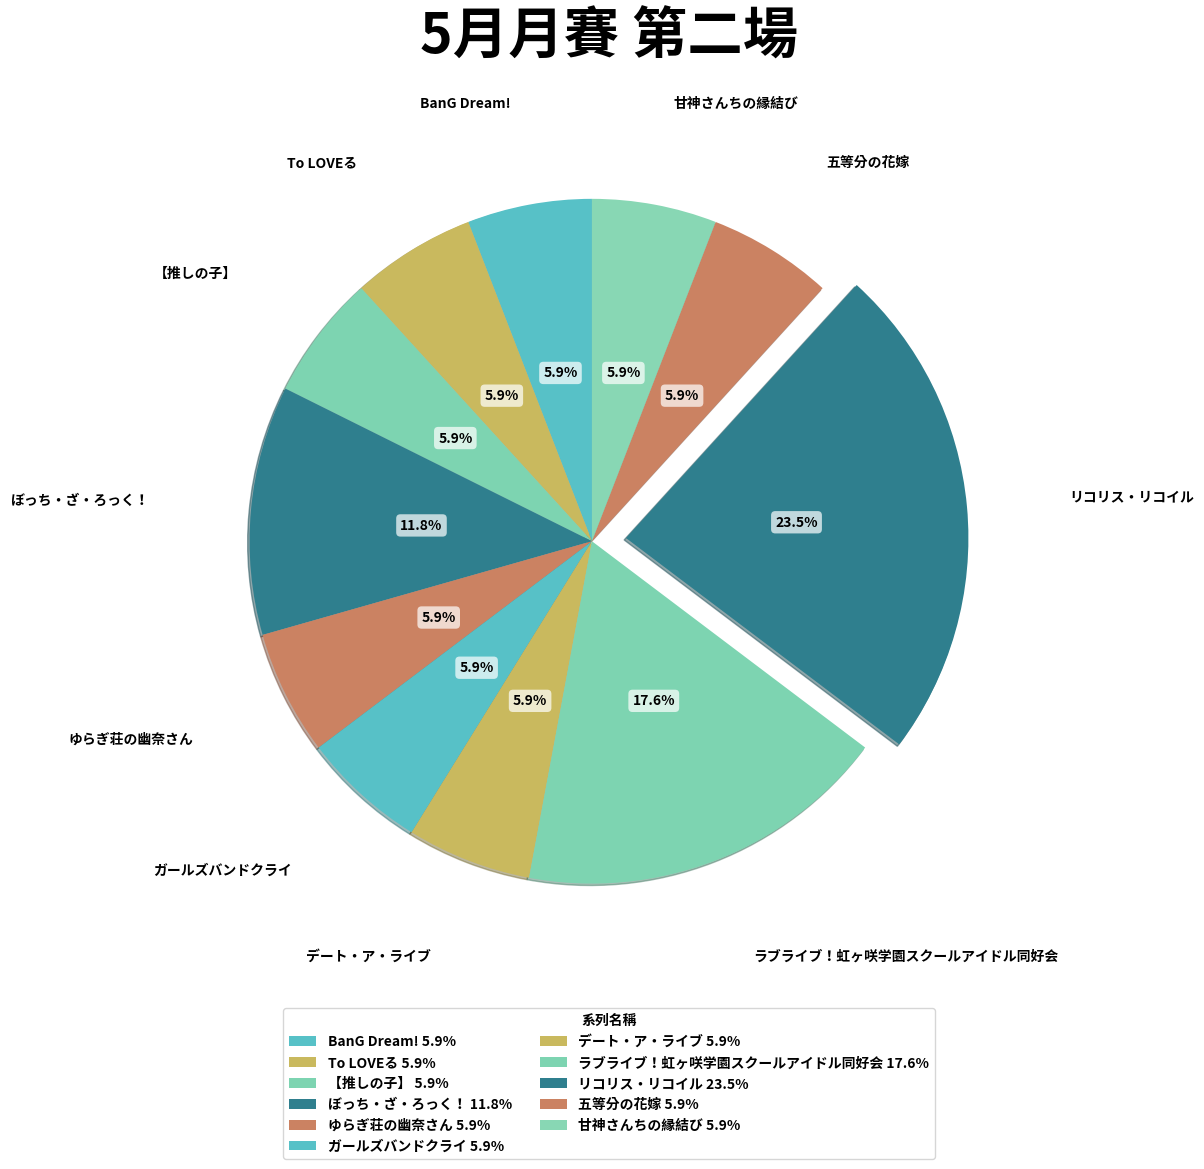

已刪除資料夾 series_images 中所有檔案


In [20]:



# 5. 畫圓餅圖
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Noto Sans CJK TC', 'Noto Sans CJK JP']
mpl.rcParams['axes.unicode_minus'] = False
font_path = 'font/NotoSansCJKtc-Bold.otf'
font_prop = fm.FontProperties(fname=font_path)

sizes = [series_count[s] for s in unique_series]
labels = unique_series

# 顏色循環，最後一個顏色特別處理
base_colors = ['#57c1c7', '#c9b95e', '#7dd4b1', '#2f7f8e', '#cb8262']
colors = [base_colors[i % len(base_colors)] for i in range(len(labels))]
if len(labels) > 1:
    colors[-1] = '#88D7B4'

explode = [0.1 if count == max(sizes) else 0 for count in sizes]
percent_labels = [f"{label} {size / sum(sizes) * 100:.1f}%" for label, size in zip(labels, sizes)]

fig, ax = plt.subplots(figsize=(14, 12))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=explode,
    shadow={'ox': -0.004, 'oy': -0.004, 'shade': 0.4},
    textprops={'fontsize': 50, 'fontweight': 'bold', 'fontproperties': font_prop},
    labeldistance=1.3,
    pctdistance=0.5
)

# 百分比加白色網底
for autotext in autotexts:
    autotext.set_bbox(dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3', alpha=0.7))


game_title = game_name
plt.title(game_title,
        
          fontweight='bold',
          fontproperties=font_prop,
          fontsize=40,
          pad=80)
plt.axis('equal')

legend = plt.legend(
    wedges, percent_labels,
    title="系列名稱",
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    prop=font_prop,
    borderaxespad=0.,
    title_fontsize=18
)

legend.get_title().set_fontproperties(font_prop)
# 計算各扇形中心角度以放置圖片 - 用 wedge 物件確保正確
wedge_angles = []
for wedge in wedges:
    theta1, theta2 = wedge.theta1, wedge.theta2
    mid_angle = np.radians((theta1 + theta2)/2)
    wedge_angles.append(mid_angle)

# 動態調整圖片大小，比例越大圖片越大
max_zoom = 0.45
min_zoom = 0.25
size_arr = np.array(sizes)
zoom_arr = min_zoom + (max_zoom - min_zoom) * (size_arr - size_arr.min()) / (size_arr.max() - size_arr.min() + 1e-8)

# 添加圖片到圓餅圖周圍（無背景無外框，佔比<5%不顯示）
for i, (series, angle, zoom) in enumerate(zip(labels, wedge_angles, zoom_arr)):
    percentage = (sizes[i] / sum(sizes)) * 100
    if percentage < 5:
        print(f"⏩ 跳過 {series} (佔比 {percentage:.1f}% < 5%)")
        continue

    english_filename = series_to_filename[series]
    img_path = os.path.join('series_images', f"{english_filename}.jpg")
    if os.path.exists(img_path):
        img_radius = 0.95
        x = img_radius * np.cos(angle)
        y = img_radius * np.sin(angle)
        try:
            img = mpimg.imread(img_path)
            imagebox = OffsetImage(img, zoom=zoom)
            ab = AnnotationBbox(
                imagebox, (x, y),
                frameon=False,
                pad=0
            )
            ax.add_artist(ab)
        except Exception as e:
            print(f"❌ 無法添加 {series} 的圖片: {str(e)}")

plt.tight_layout()
plt.savefig('deck_series_distribution_with_images.png',
           dpi=300,
           bbox_inches='tight',
           pad_inches=0.4)
plt.show()
delete_all_files_in_directory('series_images')
